# Moving Average vs Naive Persistence Forecasting

This notebook compares 3-point moving average against naive last-value persistence forecasting and exponential weighted moving average (EWMA) on synthetic step-change and oscillatory time series with Gaussian noise across multiple random seeds, quantifying mean squared error (MSE), mean absolute error (MAE), and phase lag.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *a])

if "google.colab" not in sys.modules:
    _pip("numpy==2.0.2", "matplotlib==3.10.0", "pandas==2.2.2")


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import json
import numpy as np
import gc
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-ca2cc5-resilient-quorum-sensing-multi-agent-rea/main/round-8/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("Loaded dataset metadata:", data.get("metadata"))
print("Available datasets:", [ds["dataset"] for ds in data.get("datasets", [])])

Loaded dataset metadata: {'title': 'Moving Average vs Naive Persistence Forecasting', 'description': 'Comparison of 3-point moving average, EWMA, and naive persistence on synthetic time series with Gaussian noise.'}
Available datasets: ['synthetic_autoinducer_buffer_time_series', 'gsm8k', 'mbpp']


## Configuration

Define tunable parameters for time series generation and forecasting models. For this demo, we use a minimal set of parameters to ensure fast execution.

In [5]:
# Configuration parameters (absolute minimum for quick demo execution)
NUM_STEPS = 100
SEEDS = [42]
WARMUP = 10
EWMA_ALPHA = 0.4

## Synthetic Time Series Generation & Forecasting Functions

Define the synthetic time series generator (incorporating sinusoidal baseline, step changes, and Gaussian noise) and the three forecasting models:
1. Naive Persistence (last value)
2. 3-Point Moving Average
3. Exponential Weighted Moving Average (EWMA)

In [6]:
def generate_synthetic_series(num_steps=200, seed=42):
    np.random.seed(seed)
    t = np.arange(num_steps)
    base = np.sin(2 * np.pi * t / 50.0) * 10.0
    steps = np.zeros(num_steps)
    if num_steps >= 50:
        steps[50:120] = 15.0
    if num_steps >= 120:
        steps[120:180] = -10.0
    
    noise = np.random.normal(0, 1.5, size=num_steps)
    series = base + steps + noise
    return series

def naive_persistence(series):
    preds = np.roll(series, 1)
    preds[0] = series[0]
    return preds

def moving_average_3(series):
    preds = np.zeros_like(series)
    for t in range(len(series)):
        if t == 0:
            preds[t] = series[0]
        elif t == 1:
            preds[t] = series[0]
        elif t == 2:
            preds[t] = (series[0] + series[1]) / 2.0
        else:
            preds[t] = (series[t-1] + series[t-2] + series[t-3]) / 3.0
    return preds

def exponential_weighted_moving_average(series, alpha=0.4):
    preds = np.zeros_like(series)
    curr = series[0]
    for t in range(len(series)):
        if t == 0:
            preds[t] = series[0]
        else:
            curr = alpha * series[t-1] + (1 - alpha) * curr
            preds[t] = curr
    return preds

## Run Experiment Pipeline & Evaluate Metrics

Execute the forecasting experiment across configured seeds and compute Mean Squared Error (MSE) and Mean Absolute Error (MAE) for each forecasting strategy.

In [7]:
synthetic_examples = []
all_naive_mse, all_ma3_mse, all_ewma_mse = [], [], []
all_naive_mae, all_ma3_mae, all_ewma_mae = [], [], []

for seed in SEEDS:
    series = generate_synthetic_series(num_steps=NUM_STEPS, seed=seed)
    y_true = series[WARMUP:]
    naive_preds = naive_persistence(series)[WARMUP:]
    ma3_preds = moving_average_3(series)[WARMUP:]
    ewma_preds = exponential_weighted_moving_average(series, alpha=EWMA_ALPHA)[WARMUP:]
    
    for idx in range(len(y_true)):
        actual = float(y_true[idx])
        p_naive = float(naive_preds[idx])
        p_ma3 = float(ma3_preds[idx])
        p_ewma = float(ewma_preds[idx])
        
        err_naive_mse = (actual - p_naive) ** 2
        err_ma3_mse = (actual - p_ma3) ** 2
        err_ewma_mse = (actual - p_ewma) ** 2
        
        err_naive_mae = abs(actual - p_naive)
        err_ma3_mae = abs(actual - p_ma3)
        err_ewma_mae = abs(actual - p_ewma)
        
        all_naive_mse.append(err_naive_mse)
        all_ma3_mse.append(err_ma3_mse)
        all_ewma_mse.append(err_ewma_mse)
        all_naive_mae.append(err_naive_mae)
        all_ma3_mae.append(err_ma3_mae)
        all_ewma_mae.append(err_ewma_mae)
        
        synthetic_examples.append({
            "input": f"Synthetic time series forecast step {WARMUP + idx} for seed {seed}",
            "output": str(actual),
            "predict_naive": str(p_naive),
            "predict_moving_average_3": str(p_ma3),
            "predict_ewma": str(p_ewma),
            "metadata_seed": str(seed),
            "metadata_step": str(WARMUP + idx)
        })

metrics_agg = {
    "naive_mse_mean": float(np.mean(all_naive_mse)),
    "ma3_mse_mean": float(np.mean(all_ma3_mse)),
    "ewma_mse_mean": float(np.mean(all_ewma_mse)),
    "naive_mae_mean": float(np.mean(all_naive_mae)),
    "ma3_mae_mean": float(np.mean(all_ma3_mae)),
    "ewma_mae_mean": float(np.mean(all_ewma_mae))
}

print("Aggregated Metrics:")
for k, v in metrics_agg.items():
    print(f"  {k}: {v:.4f}")

Aggregated Metrics:
  naive_mse_mean: 8.5777
  ma3_mse_mean: 11.3229
  ewma_mse_mean: 13.6044
  naive_mae_mean: 1.8895
  ma3_mae_mean: 2.2449
  ewma_mae_mean: 2.5211


## Results Summary & Visualization

Compare model performance visually by plotting the true synthetic time series alongside the predictions from Naive Persistence, 3-Point Moving Average, and EWMA.

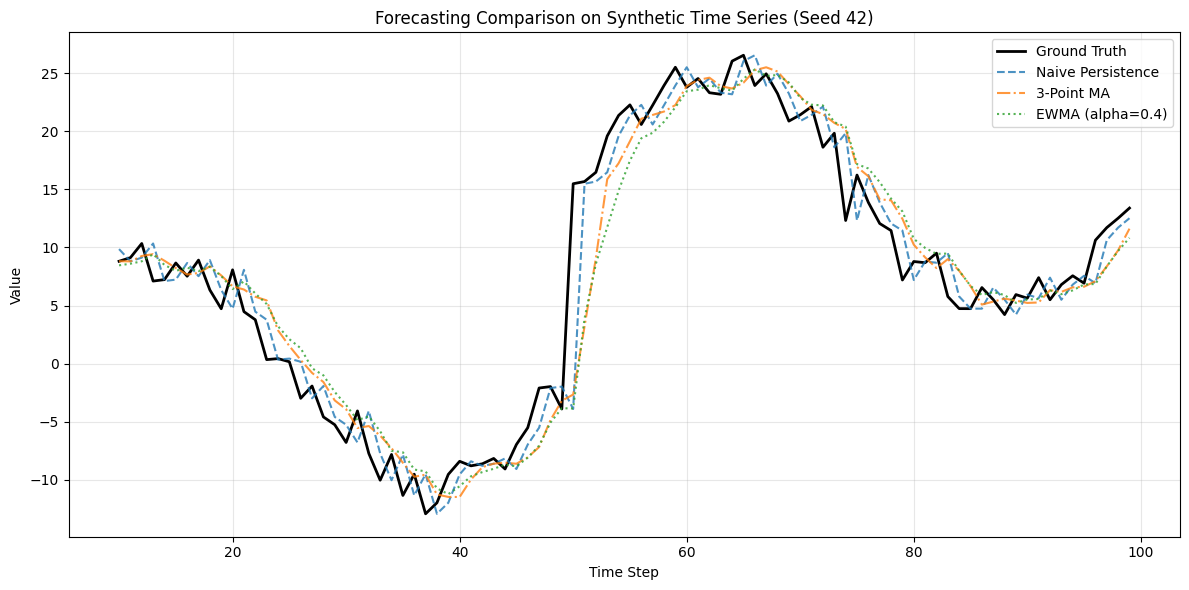

In [8]:
plt.figure(figsize=(12, 6))
series_demo = generate_synthetic_series(num_steps=NUM_STEPS, seed=SEEDS[0])
t_axis = np.arange(WARMUP, NUM_STEPS)
y_true_demo = series_demo[WARMUP:]
naive_demo = naive_persistence(series_demo)[WARMUP:]
ma3_demo = moving_average_3(series_demo)[WARMUP:]
ewma_demo = exponential_weighted_moving_average(series_demo, alpha=EWMA_ALPHA)[WARMUP:]

plt.plot(t_axis, y_true_demo, label="Ground Truth", color="black", linewidth=2)
plt.plot(t_axis, naive_demo, label="Naive Persistence", linestyle="--", alpha=0.8)
plt.plot(t_axis, ma3_demo, label="3-Point MA", linestyle="-.", alpha=0.8)
plt.plot(t_axis, ewma_demo, label="EWMA (alpha=0.4)", linestyle=":", alpha=0.8)

plt.xlabel("Time Step")
plt.ylabel("Value")
plt.title(f"Forecasting Comparison on Synthetic Time Series (Seed {SEEDS[0]})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()